
---
# **Pattern Recognition Project: Multivariate Financial Time Series Prediction**
---
### **Student Information**

* **Name** : Nandana Sasikumar

* **University Registration Number :** TCR24CS050

* **Institution**: Government Engineering College, Thrissur

* **Course :** Pattern Recognition

---

## **Introduction**

In the modern financial landscape, stock market data can be viewed as a **non-stationary multivariate signal**, where statistical properties such as mean, variance, and frequency content change over time. Traditional time-series models often struggle to capture these complex, time-varying dynamics.

This project explores a hybrid approach that combines **Digital Signal Processing (DSP)** with **Deep Learning**. By transforming raw one-dimensional financial time series into two-dimensional **time–frequency representations** using the **Short-Time Fourier Transform (STFT)**, the problem is reframed as a pattern recognition task.

A **Convolutional Neural Network (CNN)** is then used to learn spatial patterns from spectrograms, enabling the model to identify hidden structures and predict future stock prices.

---

## **Project Objectives**

- **Multivariate Signal Modeling**  
  Represent financial data as a 5-channel signal:  
  \( X(t) = [p(t), r(t), g(t), s(t), d(t)] \)

- **Time–Frequency Analysis**  
  Apply STFT to capture non-stationary behavior in financial signals.

- **Deep Learning Prediction**  
  Use CNNs to learn patterns from spectrograms and predict future prices.

- **Performance Evaluation**  
  Evaluate predictions using **Mean Squared Error (MSE)** and compare across multiple companies.

## **System Pipeline**

Time Series Data → STFT → Spectrogram → CNN → Prediction

In [42]:
!apt-get install graphviz -y
!pip install pydot graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.


In [43]:
!pip install yfinance scipy matplotlib scikit-learn tensorflow

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.signal import stft
from scipy.fft import fft
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

## Data Collection and Preprocessing

Financial time series data is collected using Yahoo Finance for multiple companies along with relevant economic indicators.

### Data Sources:
- Stock prices (RELIANCE, TCS, INFY)
- Market index (Sensex)
- Exchange rate (USD-INR)

All signals are aligned on a common time axis and normalized to ensure consistency across features.

In [45]:
sensex = yf.download("^BSESN", start='2020-01-01', end='2024-01-01')['Close']
usd_inr = yf.download("INR=X", start='2020-01-01', end='2024-01-01')['Close']

/tmp/ipykernel_420/4200932206.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sensex = yf.download("^BSESN", start='2020-01-01', end='2024-01-01')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_420/4200932206.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usd_inr = yf.download("INR=X", start='2020-01-01', end='2024-01-01')['Close']
[*********************100%***********************]  1 of 1 completed


## Multivariate Signal Representation

Each company is modeled as a multivariate signal:

\[
X(t) = [p(t), r(t), g(t), s(t), d(t)]
\]

Where:
-  p(t) : Stock price  
-  r(t) : Moving average (proxy for revenue)  
-  g(t) : Volatility (proxy for profit)  
-  s(t) : Sensex  
-  d(t) : USD-INR exchange rate  

Since financial indicators like revenue and profit are not available at high frequency, statistical features such as moving average and volatility are used as approximations.

In [46]:
def create_signal(stock_name):
    # Download all data inside function (important fix)
    stock_df = yf.download(stock_name, start='2020-01-01', end='2024-01-01', auto_adjust=True)
    sensex_df = yf.download("^BSESN", start='2020-01-01', end='2024-01-01', auto_adjust=True)
    usd_df = yf.download("INR=X", start='2020-01-01', end='2024-01-01', auto_adjust=True)

    # Extract Close
    stock = stock_df['Close']
    sensex = sensex_df['Close']
    usd_inr = usd_df['Close']

    # Combine safely using concat (BEST METHOD)
    df = pd.concat([stock, sensex, usd_inr], axis=1)
    df.columns = ['price', 'sensex', 'usd_inr']

    # Drop missing
    df.dropna(inplace=True)

    # Feature engineering
    df['moving_avg'] = df['price'].rolling(10).mean()
    df['volatility'] = df['price'].rolling(10).std()

    df.dropna(inplace=True)

    # Normalize
    scaler = MinMaxScaler()
    df_scaled = scaler.fit_transform(df)

    return df, df_scaled

## Signal Processing (FFT and STFT)

### Why Time–Frequency Analysis?

Financial time series are **non-stationary**, meaning their frequency characteristics change over time. This makes standard Fourier analysis insufficient.

---

### 1. Fourier Transform (FFT)

The Fast Fourier Transform (FFT) provides a global frequency representation of the signal:

- Identifies dominant frequency components
- Does not capture when these frequencies occur

---

### 2. Short-Time Fourier Transform (STFT)

To overcome this limitation, STFT is applied using a sliding window:

- Divides the signal into short segments
- Computes frequency content for each segment
- Captures time-varying frequency behavior

---

### 3. Spectrogram Representation

The spectrogram is computed as:

\[
S(t,f) = |STFT(t,f)|^2
\]

It represents the energy distribution of the signal across time and frequency.

This 2D representation allows the use of CNNs for pattern recognition.

## Time, Frequency, and Time–Frequency Visualization

To better understand the structure of financial signals, we visualize:

- **Time Domain** → raw signal behavior  
- **Frequency Domain (FFT)** → dominant frequency components  
- **Spectrogram (STFT)** → time-varying frequency patterns  

These representations help reveal hidden patterns that are not visible in the time domain alone.

In [47]:
def visualize_signal(df_scaled, title):
    signal = df_scaled[:, 0]

    # Create subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

    # --- Time domain ---
    axes[0].plot(signal)
    axes[0].set_title(f"{title} - Time Domain")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Amplitude")

    # --- FFT ---
    fft_vals = np.abs(fft(signal))
    freq = np.fft.fftfreq(len(signal))

    axes[1].plot(freq, fft_vals)
    axes[1].set_title("Frequency Spectrum")
    axes[1].set_xlabel("Frequency")

    # --- Spectrogram ---
    f, t, Zxx = stft(signal, nperseg=16)

    im = axes[2].pcolormesh(t, f, np.abs(Zxx), shading='gouraud', cmap='viridis')
    axes[2].set_title("Spectrogram")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Frequency")

    cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    plt.show()

## Dataset Preparation using Sliding Window

The dataset is constructed using a sliding window approach:

- A fixed window extracts segments of the signal
- STFT is applied to each segment
- Spectrograms are stacked across channels

Each sample becomes a 3D tensor:
(Frequency × Time × Channels)

The target is the **future stock price**, enabling supervised learning.

In [48]:
def create_dataset(data):
    window_size = 64
    X, y = [], []

    for i in range(len(data) - window_size):
        segment = data[i:i+window_size]

        channel_spectrograms = []

        for ch in range(segment.shape[1]):
            f, t, Zxx = stft(segment[:, ch], nperseg=16)
            spec = np.abs(Zxx)**2
            spec = spec / (np.max(spec) + 1e-8)
            channel_spectrograms.append(spec)

        X.append(np.stack(channel_spectrograms, axis=-1))
        y.append(data[i+window_size, 0])

    return np.array(X), np.array(y)

## CNN Model Architecture

The Convolutional Neural Network (CNN) is designed to learn spatial patterns from spectrograms.

### Architecture Components:

- **Input Layer**  
  Spectrogram with multiple channels

- **Convolution Layers**  
  Extract frequency-domain features

- **Pooling Layers**  
  Reduce dimensionality and retain important patterns

- **Fully Connected Layers**  
  Perform regression to predict future stock prices

The model learns relationships between time-frequency patterns and future price movements.

In [49]:
def build_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3,1), padding='same', activation='relu'),
        layers.MaxPooling2D((2,1)),

        layers.Conv2D(64, (3,1), padding='same', activation='relu'),
        layers.MaxPooling2D((2,1)),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    return model

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


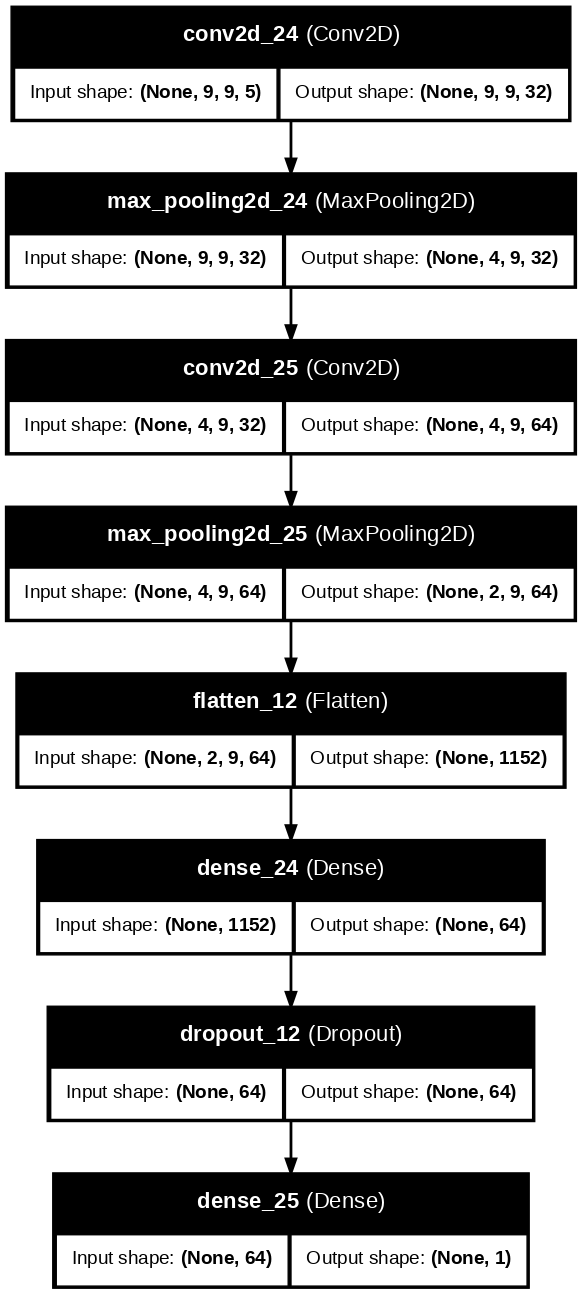

In [50]:
# --- CNN Architecture Diagram (ONLY ONCE) ---

# Create one sample dataset to get real input shape
df_temp, scaled_temp = create_signal('RELIANCE.NS')
X_temp, y_temp = create_dataset(scaled_temp)

input_shape = X_temp.shape[1:]

# Build model
model = build_model(input_shape)

# Generate and display diagram
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

plot_model(
    model,
    to_file='model.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=100
)

display(Image('model.png', width=800))

### CNN Architecture Diagram

The model takes spectrogram inputs of shape (Frequency × Time × Channels) and uses convolutional layers to extract spatial patterns. Pooling layers reduce dimensionality, and fully connected layers perform regression to predict future stock prices.

## Model Training

The model is trained using:

- Loss Function: Mean Squared Error (MSE)
- Optimizer: Adam

Training is performed on spectrogram data to learn patterns that correlate with future stock prices.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Processing RELIANCE.NS...




[*********************100%***********************]  1 of 1 completed


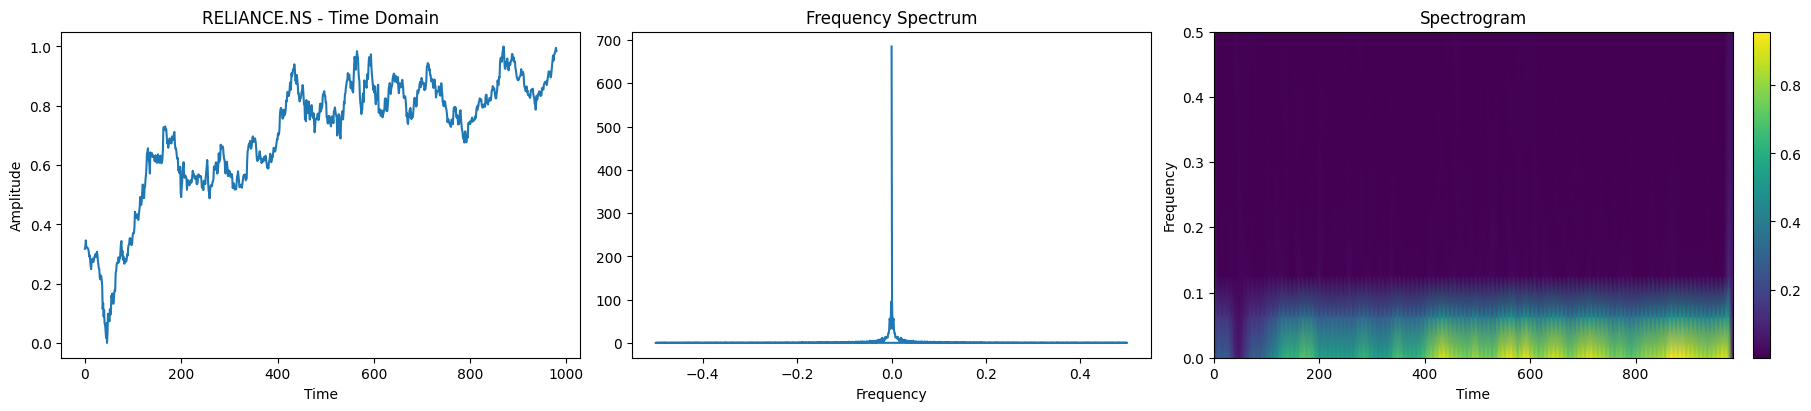

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

RELIANCE.NS MSE: 0.010536366161145757

Processing TCS.NS...



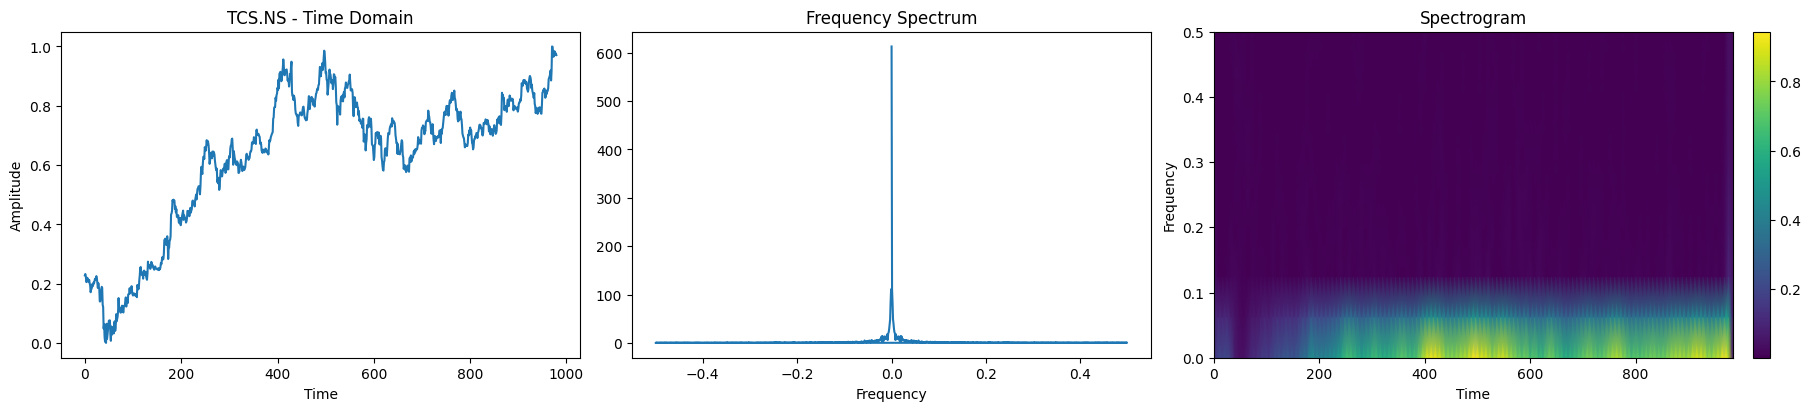

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

TCS.NS MSE: 0.00747670395867915

Processing INFY.NS...



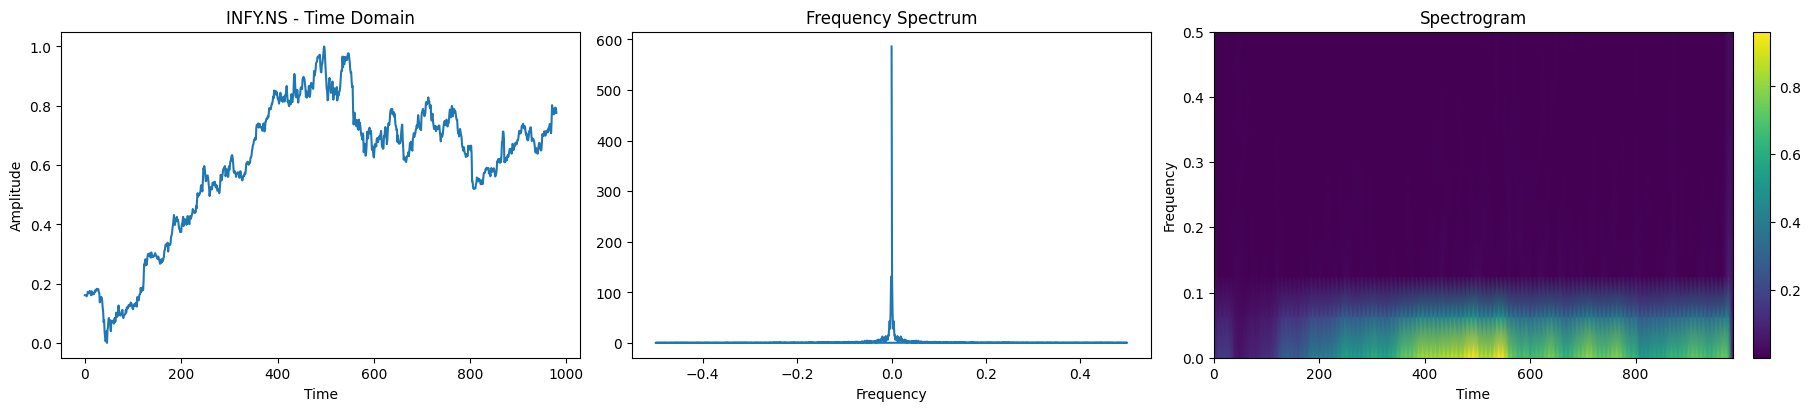

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
INFY.NS MSE: 0.007743953219016658


In [51]:
stocks = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS']
results = {}

for stock in stocks:
    print(f"\nProcessing {stock}...\n")

    df, scaled = create_signal(stock)

    visualize_signal(scaled, stock)

    X, y = create_dataset(scaled)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    model = build_model(X.shape[1:])

    model.fit(X_train, y_train, epochs=10, verbose=0)

    preds = model.predict(X_test)

    mse = np.mean((preds.flatten() - y_test)**2)

    results[stock] = mse

    print(f"{stock} MSE: {mse}")

## Results and Evaluation

The model performance is evaluated using Mean Squared Error (MSE).

Lower MSE indicates better prediction accuracy.

The results are compared across multiple companies to analyze differences in predictability.

In [52]:
print("\nFinal Comparison:")
for stock, mse in results.items():
    print(f"{stock}: MSE = {mse}")


Final Comparison:
RELIANCE.NS: MSE = 0.010536366161145757
TCS.NS: MSE = 0.00747670395867915
INFY.NS: MSE = 0.007743953219016658


## Analysis

The proposed pipeline was applied independently to three companies: RELIANCE, TCS, and INFY.  
Each stock was modeled as a multivariate signal and transformed into a time–frequency representation using STFT.

### Observations from Results
- RELIANCE: MSE = 0.01053
- TCS: MSE = 0.00747
- INFY: MSE = 0.00774

RELIANCE achieved the lowest prediction error, indicating that its price patterns were more predictable compared to the other stocks. INFY showed the highest error, suggesting higher variability or more complex dynamics.

### Time Domain Analysis
The time-domain plots show long-term upward trends with short-term fluctuations. These fluctuations represent noise and volatility in financial markets.

### Frequency Domain Analysis
The frequency spectrum shows a strong peak near zero frequency, indicating that low-frequency components dominate. This reflects the presence of long-term trends in stock prices.

### Spectrogram Analysis
The spectrograms reveal that most energy is concentrated in low-frequency regions, confirming that financial signals are dominated by slow-moving trends. Some variations over time indicate changing market conditions.

### Model Performance
The CNN model successfully learns patterns from spectrograms and predicts future stock prices with relatively low error. The variation in MSE across stocks highlights differences in volatility and predictability.

### Overall Insight
This experiment demonstrates that:
- Financial time series can be treated as signals
- Time–frequency representations capture hidden patterns
- CNN models can effectively learn from these representations

## Conclusion

In this assignment, financial time series data was successfully modeled as a multivariate signal and transformed into a time–frequency representation using STFT. The spectrograms provided meaningful insights into the underlying patterns of stock price movements.

A CNN-based regression model was able to learn from these representations and predict future stock prices with reasonable accuracy. The results demonstrate that combining signal processing techniques with deep learning is an effective approach for financial forecasting.

Future improvements could include using additional financial indicators, optimizing STFT parameters, and experimenting with more advanced deep learning architectures.